#  Below is Python code that runs an Integrate and Fire Model, Take some time to investigate the code and then complete the worksheet on Canvas titled "Worksheet 2, Integrate & Fire"

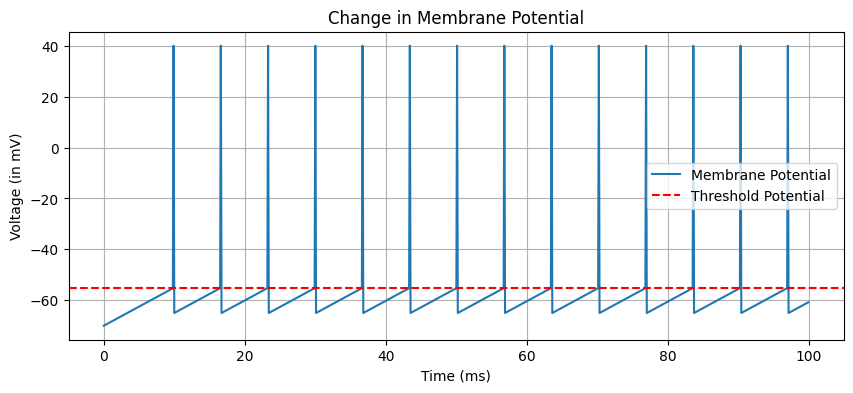

In [ ]:
# Jupyter: enable plot rendering inside the notebook (this allows us to actually show the output of the code visually)
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

# --- Neuron Parameters (realistic, in mV and pA) ---
C = 200.0 # Membrane capacitance, the ability of the membrane to store charge
V_th = -55.0 # Threshold potential, voltage required to depolarize the neuron
V_reset = -65.0 # Reset potential, voltage the neuron returns to after firing an AP
V_rest = -70.0 # Resting membrane potential, voltage of the neuron at rest
I_ext = 300.0 # External current applied to the neuron
dt = 0.1 # Timestep (in ms)


T = 100          # total simulation time in ms
dt = 0.1         # time step in ms
time = np.arange(0, T, dt)  # time vector

# --- Initialize voltage and spike times ---
V = np.full_like(time, V_rest)  # set all values to resting voltage
spike_times = []

# --- Simulation---
for i in range(1, len(time)):
    dV = (I_ext / C) * dt       # ΔV = (I / C) * dt, in mV
    V[i] = V[i-1] + dV

    if V[i] >= V_th:
        V[i-1] = 40.0           # mark spike as +40 mV (for visualization)
        V[i] = V_reset
        spike_times.append(time[i])

# --- Plotting ---
plt.figure(figsize=(10, 4))
plt.plot(time, V, label='Membrane Potential')
plt.axhline(V_th, color='r', linestyle='--', label='Threshold Potential')
plt.xlabel('Time (ms)') #what should the x be?
plt.ylabel('Voltage (in mV)') #what should the y be?
plt.title('Change in Membrane Potential') #what is a good title?
plt.grid(True)
plt.legend()
plt.show()



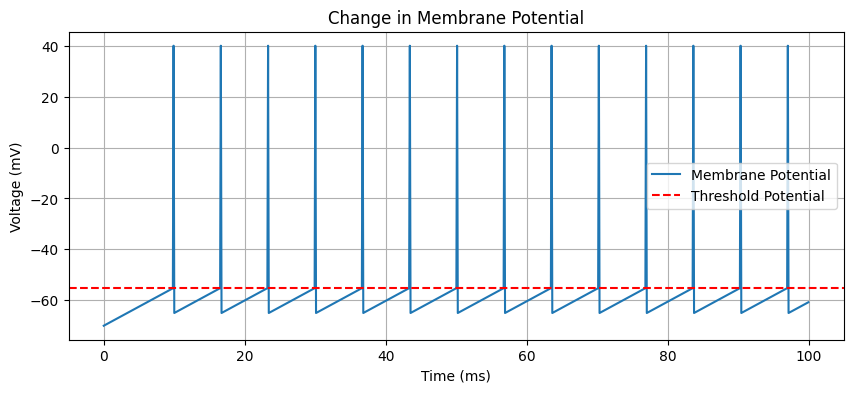

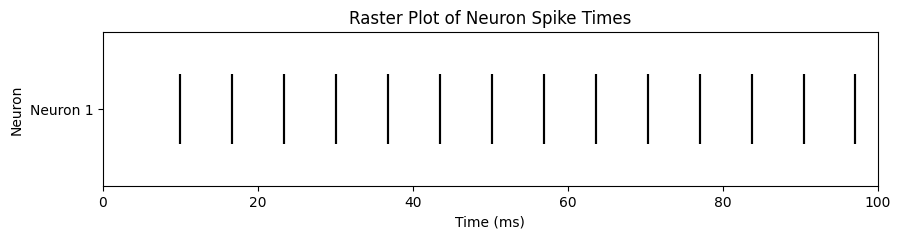

In [ ]:
# --- Simulation ---
for i in range(1, len(time)):
    dV = (I_ext / C) * dt
    V[i] = V[i-1] + dV

    if V[i] >= V_th:
        V[i-1] = 40.0
        V[i] = V_reset
        spike_times.append(time[i])


# --- Voltage Plot ---
plt.figure(figsize=(10, 4))
plt.plot(time, V, label='Membrane Potential')
plt.axhline(V_th, color='r', linestyle='--', label='Threshold Potential')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.title('Change in Membrane Potential')
plt.grid(True)
plt.legend()
plt.show()


# --- Raster Plot ---
plt.figure(figsize=(10, 2))
plt.eventplot(
    spike_times,
    lineoffsets=1,
    linelengths=0.8,
    colors='black'
)

plt.yticks([1], ['Neuron 1'])
plt.xlabel('Time (ms)')
plt.ylabel('Neuron')
plt.title('Raster Plot of Neuron Spike Times')
plt.xlim(0, T)

plt.show()